In [ ]:
!pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/22.5 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 64.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nccl-cu12
   

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
## import neccessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## seperate independent and dependent features
X = df.iloc[:,3:13]
y = df.iloc[:,13]

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
## one hot encoding for categorical columns [Geography	Gender]

Geography = pd.get_dummies(X["Geography"],drop_first=True).astype(int)
Gender = pd.get_dummies(X["Gender"],drop_first=True).astype(int)
Gender.head()


,Male
0,0
1,0
2,0
3,0
4,0


In [ ]:
#X = X.drop(["Geography","Gender"],axis=1)  # axis =1 to drop columns , 0 for rows
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
Geography.head()

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1


In [ ]:
X = X.drop(["Geography","Gender"],axis=1)

In [ ]:
X = pd.concat([X,Geography,Gender],axis=1)


In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


# Churn Modelling with Artificial Neural Networks (ANN)

This notebook demonstrates how to build and evaluate an Artificial Neural Network (ANN) to predict customer churn using the 'Churn_Modelling.csv' dataset. The process covers data loading, preprocessing, model building, training, and evaluation.

## 1. Setup and Library Imports

This section handles the initial setup, including installing necessary libraries and importing them for use throughout the notebook. We'll be using TensorFlow for building the ANN, Pandas for data manipulation, and Scikit-learn for data preprocessing and evaluation metrics.

## 2. Data Loading

Here, we load the 'Churn_Modelling.csv' dataset into a Pandas DataFrame. The `.head()` method is used to display the first few rows of the DataFrame, providing a quick overview of the data structure and content.

## 3. Data Preprocessing

This crucial step prepares the data for model training. It involves:
*   **Separating Independent and Dependent Features**: Identifying the input features (X) and the target variable (y, which indicates churn).
*   **Handling Categorical Variables**: Using one-hot encoding for categorical features like 'Geography' and 'Gender' to convert them into a numerical format that the neural network can process. `drop_first=True` is used to avoid multicollinearity.
*   **Concatenating Features**: Combining the original numerical features with the newly created one-hot encoded features.

## 4. Data Splitting and Scaling

To properly evaluate our model, the data is split into training and testing sets. Feature scaling is then applied to normalize the range of independent variables. This is important for neural networks to converge faster and perform better.

*   **Train-Test Split**: The dataset is divided into 80% for training and 20% for testing. `random_state=0` ensures reproducibility.
*   **Feature Scaling**: `StandardScaler` is used to standardize features by removing the mean and scaling to unit variance.

## 5. Model Building: Artificial Neural Network (ANN)

This section defines the architecture of our ANN using Keras. A `Sequential` model is built with multiple `Dense` layers, including an input layer, two hidden layers, and an output layer. `ReLU` (Rectified Linear Unit) activation functions are used for the hidden layers, and a `sigmoid` activation is used for the output layer, suitable for binary classification.

## 6. Model Compilation and Training

Before training, the model needs to be compiled with an optimizer, a loss function, and metrics. We also introduce early stopping to prevent overfitting.

*   **Optimizer**: `Adam` optimizer is chosen with a learning rate of 0.001.
*   **Loss Function**: `binary_crossentropy` is used as it's a binary classification problem.
*   **Metrics**: `accuracy` is chosen to monitor model performance.
*   **Early Stopping**: This callback monitors `val_loss` and stops training if the validation loss does not improve significantly for a certain number of epochs (`patience=20`), thus preventing overfitting.

## 7. Training History and Visualization

After training, we can inspect the `model_history` object to understand how the model performed during training. This includes tracking accuracy and loss on both the training and validation sets. Visualizing these metrics helps identify potential overfitting or underfitting.

## 8. Model Prediction and Evaluation

With the trained model, we make predictions on the unseen test set and evaluate its performance using various metrics. For binary classification, we convert the model's output probabilities into binary predictions (0 or 1) using a threshold of 0.5.

Key evaluation metrics include:
*   **Confusion Matrix**: Shows the counts of true positives, true negatives, false positives, and false negatives.
*   **Accuracy Score**: The proportion of correctly classified instances.
*   **F1 Score**: The harmonic mean of precision and recall, providing a balance between the two.
*   **Precision**: The proportion of true positive predictions among all positive predictions.
*   **Recall**: The proportion of true positive predictions among all actual positive instances.

## 9. Model Inspection: Weights

This section allows for a brief inspection of the trained model's weights. These weights represent the learned parameters of the neural network, indicating the strength of connections between neurons. While often difficult to interpret directly in complex networks, it confirms that the model has learned parameters.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
## initialize ANN
classifier = Sequential()

In [ ]:
## input layer
classifier.add(Dense(units=11,activation="relu"))


In [ ]:
## hidden layer 1
classifier.add(Dense(units=7,activation="relu"))

In [ ]:
## hidden layer 2
classifier.add(Dense(units=6,activation="relu"))

In [ ]:
## output layer
classifier.add(Dense(units=1,activation="sigmoid"))

In [ ]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)

classifier.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [ ]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)


Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5794 - loss: 0.6720 - val_accuracy: 0.7963 - val_loss: 0.4672
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7999 - loss: 0.4558 - val_accuracy: 0.8046 - val_loss: 0.4384
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8141 - loss: 0.4148 - val_accuracy: 0.8152 - val_loss: 0.4169
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8365 - loss: 0.4034 - val_accuracy: 0.8349 - val_loss: 0.3954
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8496 - loss: 0.3777 - val_accuracy: 0.8398 - val_loss: 0.3820
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8564 - loss: 0.3511 - val_accuracy: 0.8349 - val_loss: 0.3816
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8521 - loss: 0.3601 - val_accuracy: 0.8470 - val_loss: 0.3774
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8582 - loss: 0.3493 - 

In [ ]:
model_history.history

{'accuracy': [0.72121661901474,
  0.8023884892463684,
  0.8165702819824219,
  0.8384026885032654,
  0.8475461602210999,
  0.8512782454490662,
  0.8538906574249268,
  0.8559432625770569,
  0.8538906574249268,
  0.8550102710723877,
  0.8565030694007874,
  0.8570628762245178,
  0.8594887256622314,
  0.8596752882003784,
  0.857995867729187,
  0.8613547086715698,
  0.8611681461334229,
  0.8637805581092834,
  0.8622877597808838,
  0.8634073734283447,
  0.8630341291427612,
  0.8622877597808838,
  0.8634073734283447,
  0.8600485324859619,
  0.8634073734283447,
  0.8619145154953003,
  0.8613547086715698,
  0.8630341291427612,
  0.8619145154953003,
  0.863220751285553,
  0.8635939359664917,
  0.8630341291427612,
  0.8628475666046143,
  0.8634073734283447,
  0.867512583732605,
  0.8607949018478394,
  0.866392970085144,
  0.8639671802520752,
  0.8671393990516663,
  0.8647135496139526,
  0.8699384331703186,
  0.8688188195228577,
  0.8665795922279358,
  0.8697518110275269,
  0.8641537427902222,
  0.

Text(0.5, 0, 'epoch')

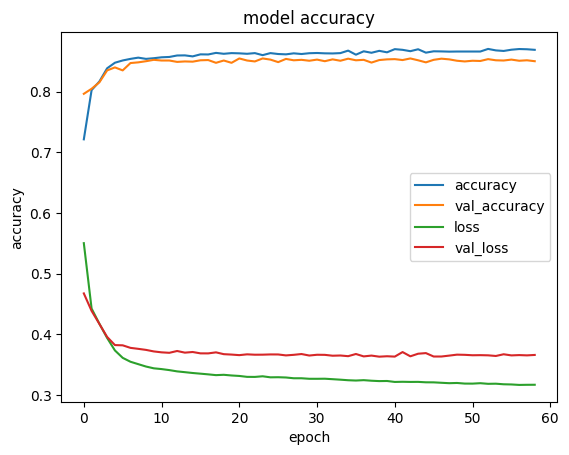

In [ ]:
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])
plt.plot(model_history.history["loss"])
plt.plot(model_history.history["val_loss"])
plt.legend(["accuracy","val_accuracy","loss","val_loss"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")

In [ ]:
y_pred = classifier.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
X_test.shape

(2000, 11)

In [ ]:
y_pred

array([[0.2891447 ],
       [0.44736496],
       [0.1451415 ],
       ...,
       [0.13260572],
       [0.11258363],
       [0.23780832]], dtype=float32)

In [ ]:
y_pred = (y_pred >= 0.5).astype(int)


In [ ]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
cm

array([[1529,   66],
       [ 212,  193]])

In [ ]:
## accuracy
accuracy_score(y_test,y_pred)

0.861

In [ ]:
## f1 score

from sklearn.metrics import f1_score
f1_score(y_test,y_pred)


0.5813253012048193

In [ ]:
## precision and recall

from sklearn.metrics import precision_score,recall_score
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
#

0.7451737451737451
0.4765432098765432


In [ ]:
## get weights

classifier.get_weights()

[array([[ 1.25734866e-01, -9.14111137e-02, -1.99443907e-01,
         -1.19929127e-02, -6.50141239e-02,  5.78981578e-01,
          1.22364843e-02,  5.52966334e-02,  4.22457576e-01,
         -2.70318329e-01, -2.35642970e-01],
        [-8.07445884e-01,  3.34260494e-01, -2.38919362e-01,
          2.65880138e-01,  9.67720747e-01, -3.14530164e-01,
         -6.80834830e-01, -9.58295166e-02, -1.98027745e-01,
          1.81967989e-01,  5.78987360e-01],
        [-1.52492151e-01, -8.19585249e-02, -3.07101488e-01,
          2.28081308e-02,  3.19074482e-01,  2.53190130e-01,
          3.71947140e-02,  6.97845444e-02,  3.73047501e-01,
         -2.11092934e-01,  4.72321287e-02],
        [-2.60189354e-01,  1.48652136e-01,  3.42844069e-01,
          1.20156817e-01,  5.41827142e-01,  4.19319838e-01,
          2.86602855e-01,  2.55235255e-01, -1.00532758e+00,
          3.93722117e-01, -1.02120943e-01],
        [ 5.64621747e-01,  1.21203876e+00,  4.19235706e-01,
          1.02763963e+00,  5.25927067e-01, -